**LSTM (Long Short-Term Memory)**
LSTM is a specialized type of Recurrent Neural Network (RNN) designed to solve the "vanishing gradient problem." While standard RNNs struggle to retain information over long sequences, LSTMs use a complex internal structure called "gates" to regulate the flow of information.
*   **Forget Gate:** Decides which information from the previous state should be discarded.
*   **Input Gate:** Decides which new information should be added to the cell state.
*   **Output Gate:** Decides what part of the cell state should be output as the hidden state.
*   **Use Case:** Ideal for tasks involving long-range dependencies, such as language translation, speech recognition, and time-series forecasting.

**GRNs (Gated Recurrent Networks)**
GRNs is a broad category of neural network architectures that utilize "gates" (mechanisms that multiply inputs by values between 0 and 1) to control the flow of information through time. 
*   **Function:** Like LSTMs, GRNs use gates to decide what to remember and what to forget, allowing the network to maintain a "memory" of past inputs.
*   **Examples:** The most prominent member of the GRN family is the **GRU (Gated Recurrent Unit)**. GRUs are a streamlined version of LSTMs that use fewer gates (Reset and Update gates), making them computationally faster and more efficient while often providing similar performance.
*   **Use Case:** Used for any sequential data processing where the model needs to selectively retain or discard information over time.

**GRU (Gated Recurrent Unit)** is a streamlined version of the Long Short-Term Memory (LSTM) network. It is a type of Recurrent Neural Network (RNN) designed to handle sequential data and solve the vanishing gradient problem by using a simplified gating mechanism.

### Key Differences from LSTM
While LSTMs use three gates (Forget, Input, and Output) and maintain two separate states (Cell State and Hidden State), GRUs combine these into a single **Hidden State** and use only two gates. This makes GRUs computationally faster and more efficient, often performing similarly to LSTMs on smaller datasets.

### The Two Gates in GRU
1.  **Update Gate ($z$):** This gate determines how much of the past information (from previous time steps) needs to be passed along to the future. It acts similarly to the Forget and Input gates in an LSTM combined.
2.  **Reset Gate ($r$):** This gate decides how much of the past information to forget. It helps the model decide how much of the previous hidden state is relevant to the current input.

### Summary Comparison

| Feature | LSTM | GRU |
| :--- | :--- | :--- |
| **Complexity** | Higher (more parameters) | Lower (fewer parameters) |
| **Gates** | 3 (Forget, Input, Output) | 2 (Update, Reset) |
| **States** | 2 (Cell state, Hidden state) | 1 (Hidden state) |
| **Speed** | Slower to train | Faster to train |
| **Performance** | Better for very long sequences | Better for smaller/medium datasets |

#
--- 
---

## **Reset Gate & Update Gate**

In a Gated Recurrent Unit (GRU), the gates are mathematical mechanisms (using the sigmoid function) that control the flow of information. They act as "valves" that decide how much data to keep and how much to discard.

### 1. The Reset Gate ($r$)
The Reset Gate determines **how much of the past information to forget** when calculating the new candidate state.

*   **Function:** It decides how much of the previous hidden state ($h_{t-1}$) is relevant to the current input.
*   **How it works:** 
    *   If the gate value is near **0**, the model "forgets" the previous hidden state, essentially treating the current input as the start of a new sequence.
    *   If the gate value is near **1**, the model "remembers" the previous state and combines it heavily with the new input.
*   **Purpose:** It allows the model to drop information that is no longer relevant to the current context (e.g., if a sentence ends and a new topic begins).

### 2. The Update Gate ($z$)
The Update Gate determines **how much of the previous information to keep** versus **how much new information to add**.

*   **Function:** It acts as a hybrid of the "Forget Gate" and "Input Gate" found in LSTMs. It decides the balance between the old hidden state and the new candidate state.
*   **How it works:**
    *   If the gate value is near **0**, the model keeps the old information and ignores the new input.
    *   If the gate value is near **1**, the model replaces the old information with the new information.
*   **Purpose:** It allows the model to maintain long-term dependencies. By setting the update gate to a low value, the model can carry a specific piece of information (like the gender of a subject in a long sentence) through many time steps without it being corrupted by intervening words.

---

### Summary Comparison

| Gate | Primary Question | Analogy |
| :--- | :--- | :--- |
| **Reset Gate** | "How much of the **past** should I ignore to prepare for this new input?" | Clearing your whiteboard before starting a new math problem. |
| **Update Gate** | "How much of the **old state** should I keep, and how much of the **new state** should I add?" | Deciding whether to overwrite a file or append new text to it. |
#
---
---

## **Hidden State & Cell State**
In the context of Recurrent Neural Networks (RNNs), **Hidden State** and **Cell State** are the "memory" mechanisms that allow the network to process sequences. While they are similar, they serve different purposes, particularly in **LSTMs**.

### 1. Hidden State ($h_t$)
The Hidden State is the **short-term memory** of the network. It is the output of the current time step and is passed forward to the next time step.

*   **Function:** It carries information about what has happened in the sequence up to the current point. It is used to make predictions at the current step (e.g., predicting the next word in a sentence).
*   **Role in GRUs:** In Gated Recurrent Units (GRUs), there is **only** a hidden state. The GRU combines everything into this one vector.
*   **Role in LSTMs:** In LSTMs, the hidden state is the "filtered" version of the memory. It is the information that is actually "exposed" to the next layer or the final output.

### 2. Cell State ($C_t$)
The Cell State is the **long-term memory** of the network. It is a unique feature of the **LSTM** architecture.

*   **Function:** It acts like a "conveyor belt" that runs through the entire sequence. It carries information across many time steps with very little modification.
*   **How it works:** Because it is updated via simple addition (rather than complex multiplications), information can flow through the cell state for a long time without being "diluted" or lost. This is specifically what prevents the **vanishing gradient problem**.
*   **Role in LSTMs:** The cell state holds the "raw" long-term information. The LSTM uses gates to decide what to add to this conveyor belt and what to remove from it.

---

### Key Differences at a Glance

| Feature | Hidden State ($h_t$) | Cell State ($C_t$) |
| :--- | :--- | :--- |
| **Memory Type** | Short-term memory. | Long-term memory. |
| **Primary Role** | Used for immediate predictions and passing information to the next step. | Used to carry information over long distances without loss. |
| **Complexity** | Highly modified by gates at every step. | Modified more conservatively (mostly via addition). |
| **Availability** | Present in both RNNs, GRUs, and LSTMs. | **Only present in LSTMs.** |

### The Analogy: The Student and the Notebook
Imagine a student reading a long textbook:

*   **The Cell State is the student's deep understanding.** As they read, they build a core concept in their mind. They don't change their fundamental understanding of the topic with every single word, but they slowly refine it as they progress through chapters.
*   **The Hidden State is the student's "working memory."** It is what they are currently thinking about or holding in their head to answer a question right now. It is a summary of the current context they are in.
#
---
---




## **Simple Example**

In [ ]:
import tensorflow as tf
tf.random.set_seed(1)

rnn_layer = tf.keras.layers.SimpleRNN(
    units=2,
    use_bias=True,
    return_sequences=True # will return the sampe size as the sequence_length, if False: only return the final result
)
# (batch_size, sequence_size, feature_size)
rnn_layer.build(sequences_shape=(None, None, 5))

# return w_xh: input to hidden, w_hh: hidden to hideen, b_h: bias
w_xh, w_oo, b_h = rnn_layer.weights
print(f'w_xh shape: {w_xh.shape}')
print(f'w_oo shape: {w_oo.shape}')
print(f'b_h shape: {b_h.shape}')

w_xh shape: (5, 2)
w_oo shape: (2, 2)
b_h shape: (2,)


**Initialize Inputs**

In [21]:
x_seq = tf.convert_to_tensor(
    [[1.0]* 5, [2.0]* 5, [3.0]*5],
    dtype=tf.float32
)
x_seq.numpy()

array([[1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3.]], dtype=float32)

**Using SimpleRNN Model**

In [23]:
output = rnn_layer(tf.reshape(x_seq, (1,3,5)))
output.numpy()

array([[[-0.2725337 , -0.3590693 ],
        [-0.23261245, -0.4106704 ],
        [-0.4303845 , -0.68866056]]], dtype=float32)

**Manually Calculation**

In [24]:
out_man = [] # save output
for t in range(len(x_seq)):
    xt = tf.reshape(x_seq[t], (1,5))
    ht = tf.matmul(xt, w_xh) + b_h
    if t > 0:
        prev_o = out_man[t-1]
    else:
        prev_o = tf.zeros(shape=(ht.shape))
    ot = ht + tf.matmul(prev_o, w_oo)
    ot = tf.math.tanh(ot)
    out_man.append(ot)
    print('Output (manual): ', ot.numpy())
    print(' SimpleRNN output: '.format(t), output[0][t].numpy())
    print()

Output (manual):  [[-0.2725337 -0.3590693]]
 SimpleRNN output:  [-0.2725337 -0.3590693]

Output (manual):  [[-0.23261245 -0.4106704 ]]
 SimpleRNN output:  [-0.23261245 -0.4106704 ]

Output (manual):  [[-0.4303845  -0.68866056]]
 SimpleRNN output:  [-0.4303845  -0.68866056]



---
---

## **BPTT (Backpropagation Trhough Time) - Vanishing**
This diagram illustrates the mathematical relationship between the **recurrent weight ($w_{hh}$)** and the stability of the **gradient** during Backpropagation Through Time (BPTT).

In a Recurrent Neural Network (RNN), the hidden state $h_t$ is calculated as:
$$h_t = \sigma(w_{hh} \cdot h_{t-1} + w_{xh} \cdot x_t)$$

When calculating the gradient of the loss with respect to the weights, the chain rule involves repeatedly multiplying by the weight $w_{hh}$ for every time step passed.

### 1. Vanishing Gradient ($|w_{hh}| < 1$)
*   **The Math:** If the weight is less than 1 (e.g., $0.99$), multiplying a number by $0.99$ repeatedly makes it smaller and smaller ($0.99 \times 0.99 \times 0.99 \dots \to 0$).
*   **The Effect:** As the gradient is propagated back through many time steps, it shrinks exponentially toward zero.
*   **The Consequence:** The model "forgets" long-term dependencies. The weights in the early layers receive almost no update, meaning the network cannot learn how an input from many steps ago affects the current output.

### 2. Exploding Gradient ($|w_{hh}| > 1$)
*   **The Math:** If the weight is greater than 1 (e.g., $1.01$), multiplying a number by $1.01$ repeatedly makes it grow exponentially ($1.01 \times 1.01 \times 1.01 \dots \to \infty$).
*   **The Effect:** The gradient grows uncontrollably as it moves backward through time.
*   **The Consequence:** This leads to massive updates to the network weights, causing the model to become unstable. This often results in `NaN` (Not a Number) values in your loss function and causes the model to fail to converge.

### 3. Desirable / Stable ($|w_{hh}| = 1$)
*   **The Math:** If the weight is exactly 1, the magnitude of the gradient remains constant regardless of how many time steps you go back ($1 \times 1 \times 1 = 1$).
*   **The Effect:** The gradient signal is preserved across time steps.
*   **The Consequence:** This allows the network to learn long-term dependencies effectively because the error signal from the current time step can reach the earliest time steps without being lost or magnified.

**Note on Modern Architectures:**
Because standard RNNs struggle with this $w_{hh}$ sensitivity, modern architectures like **LSTMs (Long Short-Term Memory)** and **GRUs (Gated Recurrent Units)** were invented. They use "gates" to create a "constant error carousel," which allows the network to maintain a stable gradient flow even when the weights aren't perfectly tuned to 1.

---
---
## **Solutions for Vanishing:**
- TBPTT
- Gradient clipping
- LSTM

#### **1) Truncated Backpropagation Through Time (TBPTT)**

Here is the distinction between standard BPTT and TBPTT in the context of the gradient problem:

#### 1. Standard BPTT (Backpropagation Through Time)
In standard BPTT, you unroll the RNN for the **entire length of the sequence** ($T$).
*   **The Gradient Problem:** If your sequence is 500 steps long, the gradient calculation involves 500 repeated multiplications of $w_{hh}$. 
*   **The Result:** This is exactly where the **Vanishing/Exploding Gradient** problem becomes most severe. The mathematical "explosion" or "vanishing" happens because the chain rule forces you to multiply the same weight matrix $T$ times.

#### 2. TBPTT (Truncated BPTT)
Because standard BPTT is computationally expensive and suffers from the gradient issues mentioned above, we use **Truncated BPTT** in practice.
*   **How it works:** Instead of unrolling the sequence for the full length $T$, you split the sequence into smaller chunks (e.g., 20 or 30 steps). You perform backpropagation only within that small window.
*   **The Trade-off:**
    *   **Pros:** It is much faster and significantly reduces the risk of exploding gradients because the chain of multiplications is limited to a small number of steps.
    *   **Cons:** It limits the "memory" of the network. Because the gradient is truncated, the model cannot learn dependencies that are longer than the truncation window. It effectively "forgets" what happened before the current chunk started.

#### Summary Comparison

| Feature | Standard BPTT | Truncated BPTT (TBPTT) |
| :--- | :--- | :--- |
| **Sequence Length** | Full sequence ($T$) | Small chunks ($k$ steps) |
| **Computation** | Very high (Memory intensive) | Low (Efficient) |
| **Gradient Stability** | High risk of Vanishing/Exploding | Lower risk (due to shorter chain) |
| **Long-term Memory** | Can theoretically learn long dependencies | Limited to the truncation window |


#### **2) Gradient Clipping:**
**Gradient Clipping** is a technique used to prevent the **Exploding Gradient** problem in Recurrent Neural Networks (RNNs). 

When gradients become extremely large (due to the repeated multiplication of weights $w_{hh} > 1$), they can cause massive, unstable updates to the model's weights, leading to `NaN` values and model divergence. Gradient clipping "caps" these values to keep them within a safe, manageable range.

There are two primary ways to implement gradient clipping:

### 1. Gradient Norm Clipping (Most Common)
Instead of looking at individual weight values, this method looks at the **L2 norm** (the total magnitude) of the entire gradient vector. If the norm exceeds a predefined threshold, the entire gradient vector is scaled down proportionally.

*   **The Logic:** If the total "size" of the gradient is too big, shrink the whole vector so its magnitude equals the threshold. This preserves the **direction** of the gradient but limits its **step size**.
*   **The Formula:** 
    $$\text{if } \|\mathbf{g}\| > \text{threshold: } \mathbf{g} = \frac{\text{threshold}}{\|\mathbf{g}\|} \cdot \mathbf{g}$$
*   **Analogy:** Imagine you are walking down a mountain. If you take a step that is calculated to be 10 miles long (which would throw you off the mountain), you instead scale that step down to only 1 foot, while still moving in the same downward direction.

### 2. Gradient Value Clipping
This method is simpler and more aggressive. It looks at every individual element in the gradient vector and forces it to stay within a specific range (e.g., between -1 and 1).

*   **The Logic:** If any single gradient value is greater than $5$, it becomes $5$. If it is less than $-5$, it becomes $-5$.
*   **The Downside:** Unlike Norm Clipping, Value Clipping can change the **direction** of the gradient vector because it might clip one dimension of the vector while leaving another untouched. This can lead to less efficient learning.

---

### Summary Comparison

| Feature | **Norm Clipping** | **Value Clipping** |
| :--- | :--- | :--- |
| **What is clipped?** | The total magnitude (norm) of the vector. | Individual elements within the vector. |
| **Direction** | **Preserves the direction** of the gradient. | **Changes the direction** of the gradient. |
| **Effectiveness** | Highly effective for stabilizing training. | Less effective; can be too "crude." |
| **Common Use** | The industry standard for RNNs/LSTMs. | Rarely used in modern deep learning. |

### How to use it in code (TensorFlow/Keras)
In Keras, you don't usually have to do this manually; you can simply pass it as an argument to your optimizer:

```python
# Using Gradient Norm Clipping
optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)

# Using Gradient Value Clipping
optimizer = tf.keras.optimizers.Adam(clipvalue=0.5)
```

#### **3) LSTM - Long Short Term Memory:**

While **Gradient Clipping** is a technique used to *fix* the problems inherent in RNNs, **LSTMs (Long Short-Term Memory)** are a structural architecture designed to *prevent* those problems from happening in the first place.

In a standard RNN, the gradient is subject to the "multiplication problem" (the $w_{hh}$ issue you saw earlier). LSTMs solve this by introducing a **"Constant Error Carousel"** through a mechanism called the **Cell State**.

Here is how LSTMs handle the gradient differently:

### 1. The "Information Highway" (Cell State)
In a standard RNN, the hidden state is modified at every step by a weight matrix and a non-linear activation function (like `tanh`). This is what causes the gradient to vanish or explode.

In an LSTM, there is a separate **Cell State ($C_t$)**. This cell state acts like a conveyor belt that runs through the entire sequence. Information can flow along this belt with very little modification, allowing the gradient to travel long distances without being repeatedly multiplied by a weight matrix that is either too large or too small.

### 2. The Gating Mechanism
LSTMs use three "gates" to control the flow of information. These gates use the `sigmoid` function (which outputs values between 0 and 1) to decide how much information to let through.

*   **Forget Gate:** Decides what information from the previous cell state is no longer useful and should be discarded.
*   **Input Gate:** Decides which new information from the current input should be added to the cell state.
*   **Output Gate:** Decides what part of the current cell state should be sent out as the hidden state to the next layer.

### 3. How this solves the Gradient Problem
The "magic" happens because of the **additive** nature of the cell state update. 

In a standard RNN, the update is **multiplicative**:
$$h_t = \text{tanh}(w \cdot h_{t-1} + \dots)$$
*(Multiplication $\to$ Exponential growth or decay)*

In an LSTM, the cell state update is **additive**:
$$C_t = (f_t \cdot C_{t-1}) + i_t \cdot \tilde{C}_t$$
*(Addition $\to$ Linear flow)*

Because the update involves **addition** rather than just multiplication, the gradient can flow through the "addition" operation during backpropagation. Even if the forget gate ($f_t$) is close to 1, the gradient is passed along almost unchanged. This allows the network to maintain a "constant error" over long sequences, effectively solving the **Vanishing Gradient** problem.

### Summary: RNN vs. LSTM

| Feature | Standard RNN | LSTM |
| :--- | :--- | :--- |
| **Core Mechanism** | Multiplicative updates | Additive updates (via Cell State) |
| **Gradient Flow** | Subject to exponential decay/growth | Protected by "gates" and addition |
| **Memory** | Short-term only | Long-term and Short-term |
| **Main Weakness** | Vanishing/Exploding Gradients | Computationally expensive (more parameters) |

**Note:** Even with LSTMs, **Gradient Clipping** is still often used in practice. While LSTMs are much better at preventing vanishing gradients, they can still experience "exploding" gradients if the weights are initialized poorly or the learning rate is too high. Therefore, they are often used together: **LSTMs for architecture + Gradient Clipping for stability.**

<img src='LSTM.png' width='800'>

<img src='LSTM_Details.png' width='800'>

### **GRUs - Gated Reecurrent Units**
<img src='RGUs.png' width='600'>
<img src='RGUs_Math.png' width='600'>

#
---
---

## **Implementing RNNs for sequence modeling in TensorFlow**

In [52]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from sklearn.preprocessing import LabelEncoder
import tensorflow_datasets as tfds

# shap
import shap

# plots and images
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

# others
import re
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

#silence TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 


random.seed(2)
%matplotlib inline

# FILL IN CODE HERE #
DATA_PATH = '' # replace with your path

``Functions``

In [53]:
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))
    return text

In [54]:
# define function for token encoder
def encode(text_tensor, label):
    text = text_tensor.numpy()[0]
    encoded_text = encoder.encode(text)
    return encoded_text, label

#  wrap the encode function to a TF Operator
def encode_map_fn(text, label):
    return tf.py_function(encode, inp=[text, label], 
                          Tout=(tf.int64, tf.int64))

---
## Read data

In [55]:
df_init = pd.read_csv('drugs_raw.csv')
print('Number of reviews:', df_init.shape[0])
print('Reviews collected between:', df_init.date.min(), 'and ', df_init.date.max())
print('Unique rating values:', np.sort(df_init.rating.unique()))
df_init.head()

Number of reviews: 215063
Reviews collected between: April 1, 2008 and  September 9, 2017
Unique rating values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,"May 20, 2012",27
1,1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192
2,2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17
3,3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10
4,4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,"November 27, 2016",37


---
## Data preprocessing

``Step 1: Remove unwanted review characters``

In [56]:
# remove HTML markup, punctuation, and other non-letter characters
df_init['review'] = df_init['review'].apply(preprocessor)

``Step 2: Create binary sentiment column``

We will define our sentiment column as follows:

   - positive (1) if rating score is between 8-10
   - negative (0) if rating score is between 1-3
    
We dill drop any reviews that are netural, i.e., rating is between 4-7.

In [57]:
# create sentiment column
df_init['sentiment'] = np.where(df_init.rating.isin((1, 2, 3)), 'negative',
                          np.where(df_init.rating.isin((8,9,10)), 'positive', 'neutral'))

# drop review if sentiment is netural
df = df_init[~df_init.sentiment.eq('neutral')]

# rename sentiment to positive = 1, negative = 0
df['sentiment'] = np.where(df.sentiment.eq('positive'), 1, 0)

Let's do a quick inspection of our rating and sentiment columns

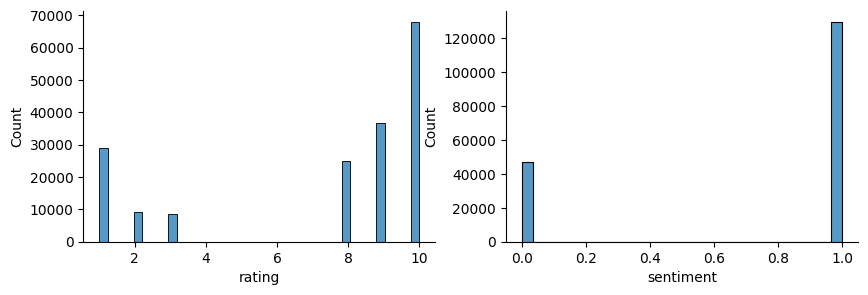

In [58]:
# rating and sentiment histogram after preprocessing
cols = ['rating', 'sentiment']
nrows, ncols = 1, 2

f, axs = plt.subplots(1, 2, figsize=(10,3))
for idx, ax in enumerate(axs):
    sns.histplot(
    data=df,
    stat="count",
    x = cols[idx],
    ax=ax
    )

    # add labels and ticks
    ax.set(xlabel=cols[idx])
    #plt.xticks(np.arange(1,11,1))
    sns.despine()

Our dataset is very imbalanced. We will correct for class imbalance by taking only 46,000 random examples from each class.

In [59]:
# randomly draw 46000 examples from each class
temp_positive = df[df.sentiment.eq(1)].sample(
    n=46000,
    replace=False
)

temp_negative = df[df.sentiment.eq(0)].sample(
    n=46000,
    replace=False
)

df_balanced = pd.concat(
    [temp_positive, temp_negative],
    axis=0)

# shuffle df_balanced
df_balanced.sample(frac=1) # frac=1 retains all the data
df_balanced.reset_index(drop=True, inplace=True) # reset index

print('After preprocessing, our data contains', df_balanced.shape[0], 'reviews.')

After preprocessing, our data contains 92000 reviews.


``Step 3: Create TensorFlow dataset and split into training, val, test``

In [60]:
df_balanced = df_balanced[['review', 'sentiment']]
df_balanced.head(5)

,review,sentiment
0,i am in my third month of taking this and abs...,1
1,i first went on this medication in march of 2...,1
2,should have started with adderall at first my...,1
3,improved cognitive function less confusion,1
4,this is the only laxative stool softener i ca...,1


<span style="color:chocolate">create TensorFlow dataset</span> 

In [61]:
# define target
target = df_balanced.pop('sentiment') # .pop removes sentiment col from df

# target and review combined tensors
data_tf = tf.data.Dataset.from_tensor_slices(
    (df_balanced[['review']].values, target.values)
)

<span style="color:chocolate">split data into train, validation, and test partitions</span> 

In [62]:
# set random seed
tf.random.set_seed(1)

# define splits for training, validation, test
splits=[0.6, 0.2, 0.2] 

# shuffle data
data_tf = data_tf.shuffle(
    df_balanced.shape[0], reshuffle_each_iteration=False)

data_tf_test = data_tf.take(int(df_balanced.shape[0]*splits[2]))
data_tf_train_valid = data_tf.skip(int(df_balanced.shape[0]*splits[2]))
data_tf_train = data_tf_train_valid.take(int(df_balanced.shape[0]*splits[0]))
data_tf_valid = data_tf_train_valid.skip(int(df_balanced.shape[0]*splits[0]))

``Step 4: Identify unique words (tokens) in the training dataset``

In [63]:
# try and except the TF tokenizer
try:
    tokenizer = tfds.features.text.Tokenizer()
except AttributeError:
    tokenizer = tfds.deprecated.text.Tokenizer()

# create an instance of the Counter class
token_counts = Counter()

for example in data_tf_train:
    tokens = tokenizer.tokenize(example[0].numpy()[0])
    token_counts.update(tokens)
    
print('Size of training vocabulary:', len(token_counts))

Size of training vocabulary: 33114


``Step 5. Encoding: sequences of words into sequences of integers``

The idea here is to map each unique word (token) in our training vocabulary to a unique integer.

In [64]:
# create an instance of the TF encoder class
try:
    encoder = tfds.features.text.TokenTextEncoder(token_counts) # token_counts contains our training vocabulary
except AttributeError:
    encoder = tfds.deprecated.text.TokenTextEncoder(token_counts)

In [65]:
# the encode_map_fn is defined at the top of the notebook
data_tf_train = data_tf_train.map(encode_map_fn)
data_tf_valid = data_tf_valid.map(encode_map_fn)
data_tf_test = data_tf_test.map(encode_map_fn)

``Step 6: Divide the dataset into mini-batches as input to the model``

In [66]:
# define batch size
batch_size = 32

# batcing of training, validation and test partitions
train_data = data_tf_train.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

valid_data = data_tf_valid.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

test_data = data_tf_test.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

In [67]:
test_data

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

``Step 7: Create features (embeddings)``

Note: this is just a stand alone. For clarity, we will code again the Embedding layer in the network architecture.

In [68]:
# Embed our training vocabulary into 10 dimensions.
vocab_size_train = len(token_counts) + 2
embedding_dim = 10

embedding_layer = tf.keras.layers.Embedding(
    vocab_size_train,
    embedding_dim,
)

Let's pass our first example in the training dataset through our embedding layer. The result replaces each integer with the vector from the embedding table:

In [69]:
for example in train_data.take(1):
    print('Seq length of our first training example:', example[0].numpy()[0].shape[0])
    print("Print integers of example:")
    print(example[0].numpy()[0])
    result = embedding_layer(example[0])

print("\nPrint embeddings of example:")
result_df = pd.DataFrame(result[0].numpy())
display(result_df.head())
print("Embedding size:", result_df.shape)

Seq length of our first training example: 142
Print integers of example:
[ 1  2  3  4  5  6  7  1  8  9 10 11 12 13 14 15 16 17 18  1  2 19 20 21
 22 23 24 25 26  4 27 28 15  5 29 30 31 32 33 34 26 35 36 26 37 38 37 30
 39 40 41 42 26 43 10 44 45 46 47 48 49 50 51 52 34 53 54 45 46 50 48 55
 50 51 52 34 53 30 56 26 57 24 58 36  1 15 26  2 19 20 59 60 26 61 34 26
  9 62 63 64 65 66  5  1 67 15 26  9 68 28 69 70 71 15  7 72 30 73 74 15
  1 75 76 73 77 78 79 80 81  0  0  0  0  0  0  0  0  0  0  0  0  0]

Print embeddings of example:


,0,1,2,3,4,5,6,7,8,9
0,0.004331,-0.043532,0.047322,0.005393,-0.048435,0.016896,0.006655,-0.036300,-0.027595,-0.029990
1,-0.040236,-0.032521,0.026008,0.019073,0.007805,0.035878,-0.002897,0.048982,0.038962,-0.007107
2,-0.023277,0.047583,-0.037703,0.010531,0.011370,-0.020657,0.018141,-0.009625,0.035848,-0.020794
3,-0.026343,-0.049911,-0.018325,-0.015448,-0.012127,-0.024202,0.033734,-0.033141,-0.012696,-0.037537
4,0.048194,-0.045778,0.005825,-0.040164,0.023400,0.048086,0.047187,0.012448,-0.018096,-0.002239


Embedding size: (142, 10)


---
## Building the RNN Model

In [70]:
vocab_size_train = len(token_counts) + 2
embedding_dim = 20

tf.random.set_seed(1)
bi_lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim = vocab_size_train,
        output_dim = embedding_dim,
        name='embed-layer'),
    tf.keras.layers.Bidirectional( # the is a wrapper layer allows a recurrent layer (like LSTM and GRUs) to process data in two directions
        tf.keras.layers.LSTM(64, name='lstm-layer'),
        name = 'bidir-lstm'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

`tf.keras.layers.Bidirectional()` is a wrapper layer that allows a recurrent layer (like LSTM or GRU) to process data in two directions: **forward** (from the beginning of the sequence to the end) and **backward** (from the end of the sequence to the beginning).

#### How it works:
1.  **Forward Pass:** One instance of the wrapped layer processes the input sequence from $t=1$ to $t=n$.
2.  **Backward Pass:** A second instance of the wrapped layer processes the input sequence in reverse, from $t=n$ to $t=1$.
3.  **Concatenation:** By default, the outputs from both directions are concatenated. If your LSTM has 64 units, the output of the `Bidirectional` layer will have 128 units (64 from forward + 64 from backward).

#### Why use it?
Standard recurrent layers only have "past" context. They know what happened before the current time step. Bidirectional layers provide **"future" context** as well. This is crucial for tasks where the meaning of a word or data point depends on what comes after it, such as:
*   **Natural Language Processing (NLP):** In the sentence *"The bank of the river is muddy,"* the word "bank" is disambiguated by the word "river" which follows it.
*   **Speech Recognition:** Understanding a sound based on the sounds that follow it.

#### Key Arguments:
*   **`layer`**: The recurrent layer to wrap (e.g., `LSTM`, `GRU`, or `SimpleRNN`).
*   **`merge`**: Determines how the forward and backward outputs are combined.
    *   `'concat'` (Default): Concatenates the outputs (doubles the output dimension).
    *   `'sum'`: Adds the outputs together.
    *   `'mul'`: Multiplies the outputs.
    *   `'ave'`: Averages the outputs.

In [71]:
bi_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed-layer (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir-lstm (Bidirectional)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [75]:
bi_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

history = bi_lstm_model.fit(
    train_data,
    validation_data = valid_data,
    batch_size=64,
    epochs=5
)

Epoch 1/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.8724 - loss: 0.3187 - val_accuracy: 0.8747 - val_loss: 0.3152
Epoch 2/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.9086 - loss: 0.2411 - val_accuracy: 0.8868 - val_loss: 0.2890
Epoch 3/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.9297 - loss: 0.1914 - val_accuracy: 0.8889 - val_loss: 0.2785
Epoch 4/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.9462 - loss: 0.1542 - val_accuracy: 0.8905 - val_loss: 0.2857
Epoch 5/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 77s 44ms/step - accuracy: 0.9575 - loss: 0.1258 - val_accuracy: 0.8957 - val_loss: 0.3076
